In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print(" Libraries imported successfully")

 Libraries imported successfully


In [46]:
df = pd.read_csv("house_prices.csv")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 187531, Columns: 21


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [47]:

df.info()
df.describe()
df.isna().mean().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [48]:
def parse_price(value):
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    try:
        if 'cr' in value:
            return float(value.replace('cr', '').strip()) * 10000000
        elif 'lac' in value:
            return float(value.replace('lac', '').strip()) * 100000
        else:
            return float(value)
    except:
        return None

df['price_clean'] = df['Amount(in rupees)'].apply(parse_price)
df = df.dropna(subset=['price_clean'])
print(f"After cleaning price: {len(df)} rows")
df[['Amount(in rupees)', 'price_clean']].head()


After cleaning price: 177847 rows


,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


In [49]:

def extract_number(text):
    if pd.isna(text) or not isinstance(text, str):
        return None
    numbers = re.findall(r'[\d.]+', text)
    if numbers:
        return float(numbers[0])
    return None

def extract_floor(text):
    if pd.isna(text) or not isinstance(text, str):
        return None
    text = text.lower().strip()
    if 'ground' in text:
        return 0
    elif 'basement' in text:
        return -1
    numbers = re.findall(r'[\d.]+', text)
    if numbers:
        return float(numbers[0])
    return None

df['Carpet_Area'] = df['Carpet Area'].apply(extract_number)
df = df.dropna(subset=['Carpet_Area'])

df['Bathroom'] = df['Bathroom'].apply(extract_number)
df['Balcony'] = df['Balcony'].apply(extract_number)
df['Car_Parking'] = df['Car Parking'].apply(extract_number)

df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Balcony'] = df['Balcony'].fillna(0)
df['Car_Parking'] = df['Car_Parking'].fillna(0)

df['Floor'] = df['Floor'].apply(extract_floor)
df['Floor'] = df['Floor'].fillna(0)

df[['Carpet_Area', 'Bathroom', 'Balcony', 'Car_Parking', 'Floor']].head()

,Carpet_Area,Bathroom,Balcony,Car_Parking,Floor
0,500.0,1.0,2.0,0.0,10.0
1,473.0,2.0,0.0,1.0,3.0
2,779.0,2.0,0.0,1.0,10.0
3,530.0,1.0,1.0,0.0,1.0
4,635.0,2.0,0.0,1.0,20.0


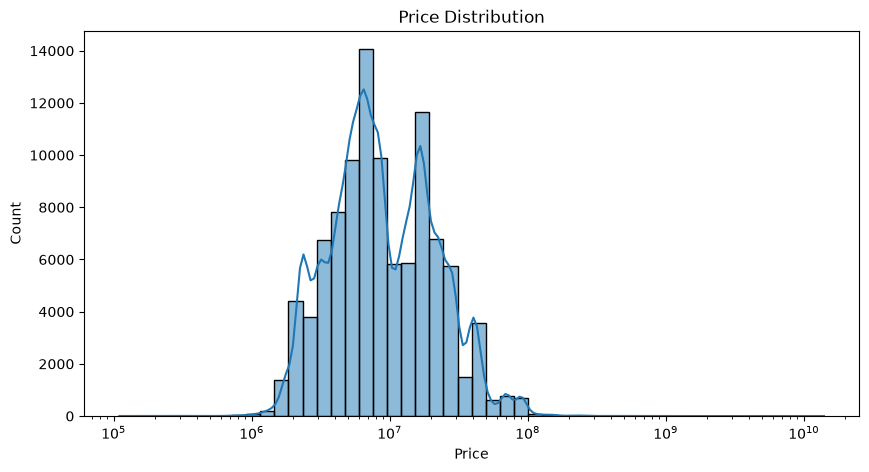

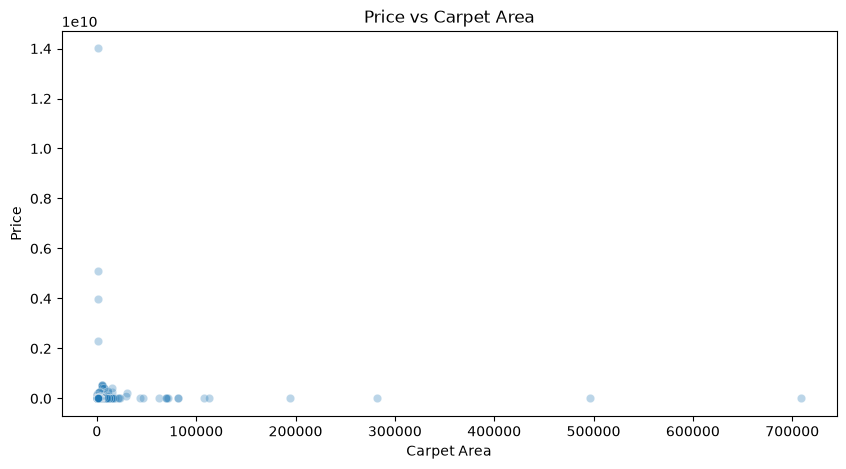

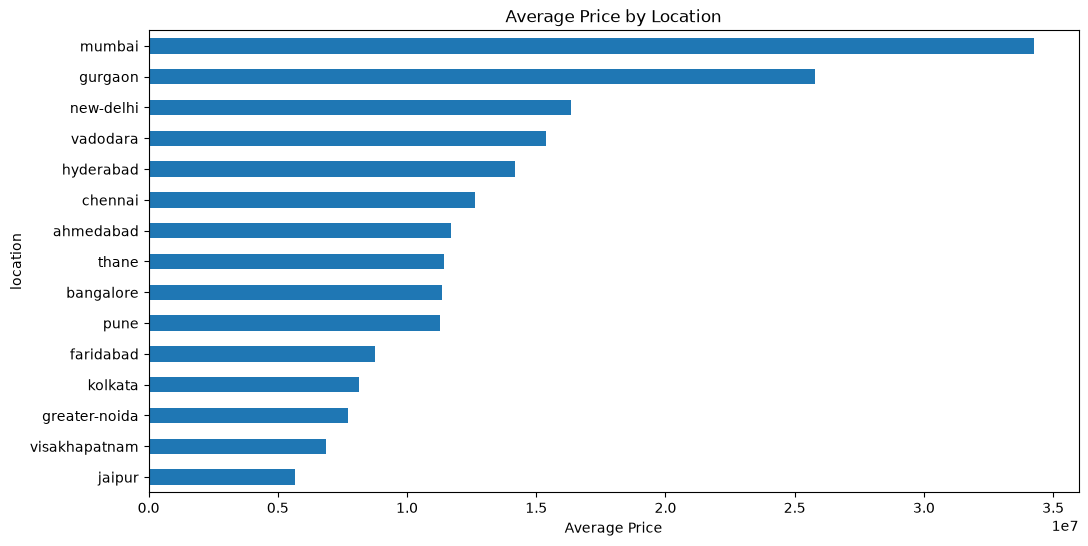

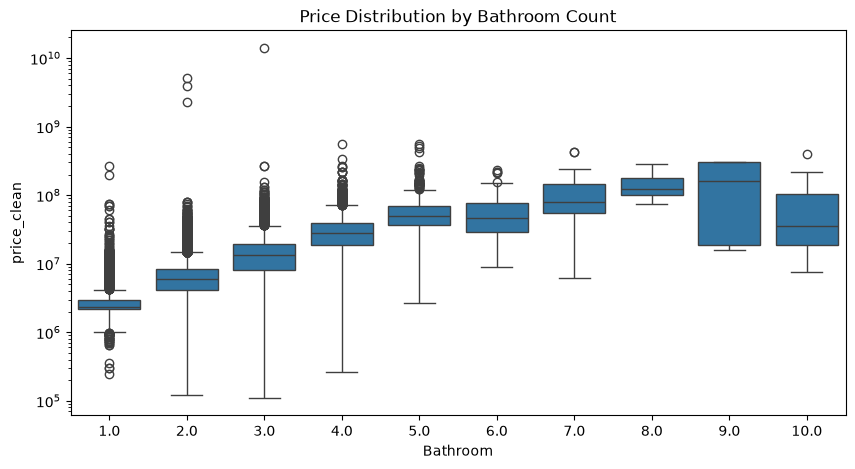

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(df['price_clean'], bins=50, log_scale=True, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Carpet_Area', y='price_clean', alpha=0.3)
plt.title('Price vs Carpet Area')
plt.xlabel('Carpet Area')
plt.ylabel('Price')
plt.show()

top_locations = df['location'].value_counts().head(15).index
df_top = df[df['location'].isin(top_locations)]
plt.figure(figsize=(12,6))
df_top.groupby('location')['price_clean'].mean().sort_values().plot(kind='barh')
plt.title('Average Price by Location')
plt.xlabel('Average Price')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Bathroom', y='price_clean')
plt.title('Price Distribution by Bathroom Count')
plt.yscale('log')
plt.show()

In [51]:

numeric_features = ['Carpet_Area', 'Bathroom', 'Balcony', 'Car_Parking', 'Floor']
categorical_features = ['location', 'Furnishing', 'Transaction', 'Ownership']

X = df[numeric_features + categorical_features]
y = df['price_clean']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 81217, Test size: 20305


In [52]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

model_lr = Pipeline([
    ('prep', preprocessor),
    ('reg', LinearRegression())
])
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

model_rf = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=100, random_state=42))
])
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

print(" Models trained successfully")

✅ Models trained successfully


Linear Regression:
MAE: 5,765,366
RMSE: 18,469,348
R2: 0.247

Random Forest:
MAE: 1,723,190
RMSE: 38,791,474
R2: -2.321

Best model: Linear Regression


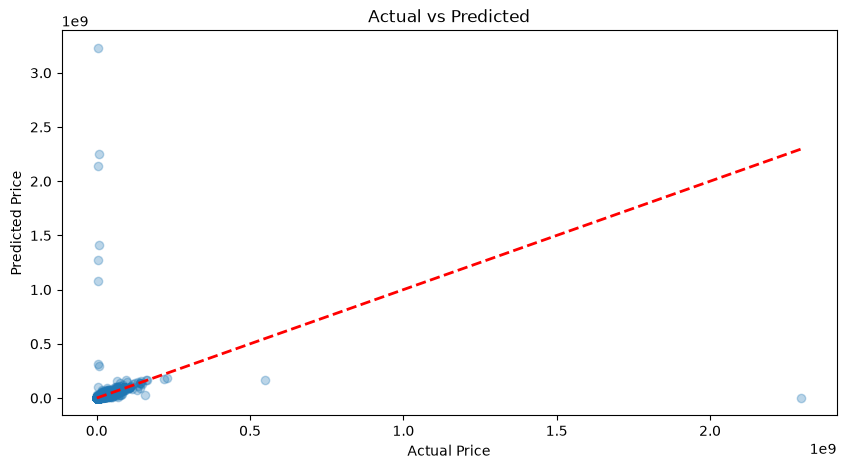

In [53]:
print("Linear Regression:")
print(f"MAE: {mean_absolute_error(y_test, pred_lr):,.0f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred_lr):,.0f}")
print(f"R2: {r2_score(y_test, pred_lr):.3f}")

print("\nRandom Forest:")
print(f"MAE: {mean_absolute_error(y_test, pred_rf):,.0f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred_rf):,.0f}")
print(f"R2: {r2_score(y_test, pred_rf):.3f}")

if r2_score(y_test, pred_rf) > r2_score(y_test, pred_lr):
    best_model = model_rf
    print("\nBest model: Random Forest")
else:
    best_model = model_lr
    print("\nBest model: Linear Regression")

plt.figure(figsize=(10,5))
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

In [54]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/house_price.pkl')
print("Model saved: models/house_price.pkl")

all_locations = df['location'].value_counts().head(50).index.tolist()
with open('models/locations.json', 'w') as f:
    json.dump(all_locations, f)
print(f"Saved {len(all_locations)} locations")

loaded_model = joblib.load('models/house_price.pkl')
sample = X_test.iloc[[0]]
pred = loaded_model.predict(sample)
print(f"Test prediction: {pred[0]:,.0f}")

print("Done.")

Model saved: models/house_price.pkl
Saved 50 locations
Test prediction: 23,404,340
Done.


Model saved: models/house_price.pkl
Saved 50 locations
Test prediction: 23,404,340
Done.
